# Notebook 06 — Run Estimator

This notebook builds functions to estimate Runs Scored and Runs Allowed per 162-game season from a 26-man roster.

Runs Scored approach:
- Regress each hitter's wOBA toward the league mean (Marcel-style, k=200 PA) and blend 50/50 with regressed xwOBA for a more stable talent estimate
- Weight by projected PA share using actual PA proportions
- Apply home park factor

Runs Allowed approach:
- Blend SIERA (40%), FIP (30%), and ERA (30%) to combine skill signal, defense effects, and sequencing
- Apply a 1.08x unearned-run factor (SIERA/FIP/ERA estimate earned runs; actual RA includes unearned)
- Weight by projected IP share using actual IP proportions
- Apply home park factor

Back-test: Run on all 30 real 2025 rosters and compare to actual RS/RA.

In [24]:
import os, sys, time, warnings
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

DATA = os.path.join("..", "data")

# load master data and park factors
master = pd.read_parquet(os.path.join(DATA, "master_players.parquet"))
park_factors = pd.read_parquet(os.path.join(DATA, "park_factors.parquet"))

hitters = master[master["player_type"] == "hitter"].copy()
pitchers = master[master["player_type"] == "pitcher"].copy()

print(f"Hitters: {len(hitters)}, Pitchers: {len(pitchers)}, Park factors: {len(park_factors)}")

Hitters: 537, Pitchers: 656, Park factors: 30


In [25]:
# 2025 league constants (PA-weighted from master data)
LG_WOBA = 0.315
WOBA_SCALE = 1.232
LG_R_PER_PA = 0.118
FIP_CONSTANT = 3.135

# Regression constant for hitters (Marcel-style: regressed = (n*stat + k*lg) / (n + k))
# k=100: starters (400-700 PA) keep 80-88% of signal, bench (150-300 PA) keep 60-75%
WOBA_REG_PA = 100

# Unearned run adjustment: ~8% of all runs are unearned.
UNEARNED_RUN_FACTOR = 1.08

# Pitching blend weights (SIERA captures sequencing + skill, FIP is defense-independent,
# ERA captures actual defense quality)
SIERA_WEIGHT = 0.40
FIP_WEIGHT = 0.30
ERA_WEIGHT = 0.30
LG_PITCHER_RATE = 4.10  # league-average fallback rate

# Team-level allocation
TEAM_PA_162 = 6000      # matches actual PA coverage in master data (~6003/team)
TEAM_IP_162 = 1458      # 9 IP/game × 162
STARTER_BENCH_SPLIT = 0.85
SP_IP_SHARE = 845 / TEAM_IP_162
RP_IP_SHARE = 1 - SP_IP_SHARE

print(f"Team PA/season:  {TEAM_PA_162}")
print(f"Team IP/season:  {TEAM_IP_162}")
print(f"SP IP budget:    {TEAM_IP_162 * SP_IP_SHARE:.0f}")
print(f"RP IP budget:    {TEAM_IP_162 * RP_IP_SHARE:.0f}")
print(f"Starter PA share: {STARTER_BENCH_SPLIT:.0%}")
print(f"Bench PA share:   {1-STARTER_BENCH_SPLIT:.0%}")
print(f"wOBA regression k: {WOBA_REG_PA} PA")
print(f"Pitching blend: {SIERA_WEIGHT:.0%} SIERA + {FIP_WEIGHT:.0%} FIP + {ERA_WEIGHT:.0%} ERA")

Team PA/season:  6000
Team IP/season:  1458
SP IP budget:    845
RP IP budget:    613
Starter PA share: 85%
Bench PA share:   15%
wOBA regression k: 100 PA
Pitching blend: 40% SIERA + 30% FIP + 30% ERA


## 2. Run estimator functions

In [27]:
def _regress(observed, sample_size, lg_mean, k):
    """Marcel-style regression toward league mean."""
    return (sample_size * observed + k * lg_mean) / (sample_size + k)


def estimate_runs_scored(lineup_ids, bench_ids, park_factor=100,
                          hitter_df=hitters, lg_woba=LG_WOBA,
                          woba_scale=WOBA_SCALE, lg_r_pa=LG_R_PER_PA):
    """
    Estimate runs scored per 162 games.
    
    Uses a 50/50 blend of regressed wOBA and regressed xwOBA for each hitter.
    Regression pulls small-sample hitters toward the league mean.
    PA allocation uses actual PA proportions from the data.
    """
    hitter_lookup = hitter_df.set_index("mlbam_id")
    
    def _get_blended_woba(pid):
        if pid in hitter_lookup.index:
            row = hitter_lookup.loc[pid]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            woba = row["wOBA"] if pd.notna(row.get("wOBA")) else lg_woba
            xwoba = row["xwOBA"] if pd.notna(row.get("xwOBA")) else woba
            pa = float(row["PA"]) if pd.notna(row.get("PA")) else 0
            
            woba_reg = _regress(woba, pa, lg_woba, WOBA_REG_PA)
            xwoba_reg = _regress(xwoba, pa, lg_woba, WOBA_REG_PA)
            return 0.5 * woba_reg + 0.5 * xwoba_reg
        return lg_woba
    
    def _get_pa(pid):
        if pid in hitter_lookup.index:
            pa = hitter_lookup.loc[pid, "PA"]
            if isinstance(pa, pd.Series):
                pa = pa.iloc[0]
            if pd.notna(pa):
                return float(pa)
        return 0.0
    
    # starters: 85% of team PA, distributed by actual PA share
    starter_pa_total = TEAM_PA_162 * STARTER_BENCH_SPLIT
    starter_actual_pa = [_get_pa(pid) for pid in lineup_ids[:9]]
    total_starter_pa = sum(starter_actual_pa)
    
    starter_runs = 0.0
    for i, pid in enumerate(lineup_ids[:9]):
        if total_starter_pa > 0:
            pa_share = starter_actual_pa[i] / total_starter_pa
        else:
            pa_share = 1.0 / min(len(lineup_ids), 9)
        pa = starter_pa_total * pa_share
        blended_woba = _get_blended_woba(pid)
        runs_per_pa = (blended_woba - lg_woba) / woba_scale + lg_r_pa
        starter_runs += runs_per_pa * pa
    
    # bench: 15% of team PA, weighted by actual PA
    bench_pa_total = TEAM_PA_162 * (1 - STARTER_BENCH_SPLIT)
    if bench_ids:
        bench_actual_pa = [_get_pa(pid) for pid in bench_ids]
        total_bench_pa = sum(bench_actual_pa)
        bench_runs = 0.0
        for i, pid in enumerate(bench_ids):
            if total_bench_pa > 0:
                pa_share = bench_actual_pa[i] / total_bench_pa
            else:
                pa_share = 1.0 / len(bench_ids)
            pa = bench_pa_total * pa_share
            blended_woba = _get_blended_woba(pid)
            runs_per_pa = (blended_woba - lg_woba) / woba_scale + lg_r_pa
            bench_runs += runs_per_pa * pa
    else:
        bench_runs = lg_r_pa * bench_pa_total
    
    total_runs = starter_runs + bench_runs
    
    # Apply park factor (half of games at home)
    pf_adj = (park_factor / 100 + 1) / 2
    total_runs *= pf_adj
    
    return round(total_runs)


def estimate_runs_allowed(sp_ids, rp_ids, park_factor=100,
                           pitcher_df=pitchers):
    """
    Estimate runs allowed per 162 games.
    
    Uses a 40/30/30 SIERA/FIP/ERA blend.
    SIERA captures sequencing and batted-ball skill better than FIP alone.
    IP allocation uses actual IP proportions.
    """
    pitcher_lookup = pitcher_df.set_index("mlbam_id")
    
    def _get_pitching_rate(pid):
        """Return blended pitching rate."""
        if pid in pitcher_lookup.index:
            row = pitcher_lookup.loc[pid]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            
            # Get available metrics
            siera = float(row["SIERA"]) if pd.notna(row.get("SIERA")) else None
            fip = None
            for col in ["FIP", "xFIP"]:
                if pd.notna(row.get(col)):
                    fip = float(row[col])
                    break
            era = float(row["ERA"]) if pd.notna(row.get("ERA")) else None
            
            # Build weighted blend from available metrics
            total_weight = 0
            blended = 0
            if siera is not None:
                blended += SIERA_WEIGHT * siera
                total_weight += SIERA_WEIGHT
            if fip is not None:
                blended += FIP_WEIGHT * fip
                total_weight += FIP_WEIGHT
            if era is not None:
                blended += ERA_WEIGHT * era
                total_weight += ERA_WEIGHT
            
            if total_weight > 0:
                return blended / total_weight
        
        return LG_PITCHER_RATE
    
    def _get_ip(pid):
        if pid in pitcher_lookup.index:
            row = pitcher_lookup.loc[pid]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            if "IP" in row.index and pd.notna(row["IP"]):
                return float(row["IP"])
        return 0.0
    
    # starting pitchers: share ~845 IP, weighted by actual IP
    sp_ip_total = TEAM_IP_162 * SP_IP_SHARE
    sp_actual_ip = [_get_ip(pid) for pid in sp_ids]
    total_sp_actual = sum(sp_actual_ip)
    
    sp_ra = 0.0
    for i, pid in enumerate(sp_ids):
        rate = _get_pitching_rate(pid)
        if total_sp_actual > 0:
            ip_share = sp_actual_ip[i] / total_sp_actual
        else:
            ip_share = 1.0 / max(len(sp_ids), 1)
        ip = sp_ip_total * ip_share
        sp_ra += (rate / 9) * ip
    
    # relievers: share remaining ~613 IP, weighted by actual IP
    rp_ip_total = TEAM_IP_162 * RP_IP_SHARE
    rp_actual_ip = [_get_ip(pid) for pid in rp_ids]
    total_rp_actual = sum(rp_actual_ip)
    
    rp_ra = 0.0
    for i, pid in enumerate(rp_ids):
        rate = _get_pitching_rate(pid)
        if total_rp_actual > 0:
            ip_share = rp_actual_ip[i] / total_rp_actual
        else:
            ip_share = 1.0 / max(len(rp_ids), 1)
        ip = rp_ip_total * ip_share
        rp_ra += (rate / 9) * ip
    
    total_ra = sp_ra + rp_ra
    
    # unearned run adjustment
    total_ra *= UNEARNED_RUN_FACTOR
    
    # apply park factor (half of games at home)
    pf_adj = (park_factor / 100 + 1) / 2
    total_ra *= pf_adj
    
    return round(total_ra)

## 3. Build team rosters from master table

Group hitters and pitchers by team directly from the master table. This avoids the MLB API `fullSeason` roster problem where traded players appear on multiple teams (195 players are double-counted with fullSeason rosters, including 35 hitters with 200+ PA like Rafael Devers appearing on both Boston and SF).

We also fetch actual 2025 standings for RS/RA to back-test against.

In [29]:
BASE = "https://statsapi.mlb.com/api/v1"

# get all team IDs and full names from teams endpoint
teams_resp = requests.get(f"{BASE}/teams?sportId=1&season=2025", timeout=30)
team_id_to_name = {t["id"]: t["name"] for t in teams_resp.json()["teams"]}

# get actual RS/RA from 2025 standings
time.sleep(0.5)
standings_resp = requests.get(
    f"{BASE}/standings?leagueId=103,104&season=2025&standingsTypes=regularSeason",
    timeout=30
)
actual = {}
for div in standings_resp.json()["records"]:
    for t in div["teamRecords"]:
        tid = t["team"]["id"]
        # Use the full team name from the teams endpoint for consistent matching
        full_name = team_id_to_name.get(tid, t["team"]["name"])
        actual[full_name] = {
            "team_id": tid,
            "wins": t["wins"],
            "losses": t["losses"],
            "RS_actual": t["runsScored"],
            "RA_actual": t["runsAllowed"],
        }

print(f"Standings loaded for {len(actual)} teams")
print(f"Sample keys: {list(actual.keys())[:5]}")

Standings loaded for 30 teams
Sample keys: ['Toronto Blue Jays', 'New York Yankees', 'Boston Red Sox', 'Tampa Bay Rays', 'Baltimore Orioles']


In [30]:
# build team rosters directly from master table 
# Each player appears once under their current team

# map team full names to park factor short names
pf_map = {}
for _, row in park_factors.iterrows():
    pf_map[row["team"].strip()] = row["park_factor_5yr"]

TEAM_TO_PF = {
    "Los Angeles Angels": "Angels", "Arizona Diamondbacks": "Diamondbacks",
    "Baltimore Orioles": "Orioles", "Boston Red Sox": "Red Sox",
    "Chicago Cubs": "Cubs", "Cincinnati Reds": "Reds",
    "Cleveland Guardians": "Guardians", "Colorado Rockies": "Rockies",
    "Detroit Tigers": "Tigers", "Houston Astros": "Astros",
    "Kansas City Royals": "Royals", "Los Angeles Dodgers": "Dodgers",
    "Washington Nationals": "Nationals", "New York Mets": "Mets",
    "Oakland Athletics": "Athletics", "Athletics": "Athletics",
    "Pittsburgh Pirates": "Pirates",
    "San Diego Padres": "Padres", "Seattle Mariners": "Mariners",
    "San Francisco Giants": "Giants", "St. Louis Cardinals": "Cardinals",
    "Tampa Bay Rays": "Rays", "Texas Rangers": "Rangers",
    "Toronto Blue Jays": "Blue Jays", "Minnesota Twins": "Twins",
    "Philadelphia Phillies": "Phillies", "Atlanta Braves": "Braves",
    "Chicago White Sox": "White Sox", "Miami Marlins": "Marlins",
    "New York Yankees": "Yankees", "Milwaukee Brewers": "Brewers",
}

def get_park_factor(team_name):
    short = TEAM_TO_PF.get(team_name, "")
    return pf_map.get(short, 100)

team_rosters = {}

# get all unique teams from master table
all_team_names = master["team"].unique()

for tname in sorted(all_team_names):
    # hitters: sort by PA, top 9 = lineup, next 4 = bench
    team_hitters = hitters[hitters["team"] == tname].sort_values("PA", ascending=False)
    lineup = team_hitters["mlbam_id"].tolist()[:9]
    bench = team_hitters["mlbam_id"].tolist()[9:13]
    
    # pitchers: sort by GS to find starters, then by IP for relievers
    team_pitchers = pitchers[pitchers["team"] == tname].copy()
    team_pitchers = team_pitchers.sort_values(["GS", "IP"], ascending=False)
    
    sp_ids = team_pitchers.head(5)["mlbam_id"].tolist()
    remaining = team_pitchers.iloc[5:]
    rp_ids = remaining[remaining["IP"] > 0].head(8)["mlbam_id"].tolist()
    if not rp_ids:
        rp_ids = remaining.head(8)["mlbam_id"].tolist()
    
    team_rosters[tname] = {
        "name": tname,
        "lineup": lineup,
        "bench": bench,
        "sp": sp_ids,
        "rp": rp_ids,
        "park_factor": get_park_factor(tname),
    }

print(f"Rosters built for {len(team_rosters)} teams")

# show one example
ex = team_rosters["New York Yankees"]
print(f"\nExample — {ex['name']} (PF={ex['park_factor']}):")
print(f"  Lineup (9): {ex['lineup']}")
print(f"  Bench ({len(ex['bench'])}): {ex['bench']}")
print(f"  SP (5): {ex['sp']}")
print(f"  RP ({len(ex['rp'])}): {ex['rp']}")

Rosters built for 30 teams

Example — New York Yankees (PF=99):
  Lineup (9): [592450, 641355, 683011, 663757, 502671, 665862, 700250, 669224, 691176]
  Bench (4): [519317, 672724, 518934, 665828]
  SP (5): [607074, 701542, 608331, 657376, 693645]
  RP (8): [661563, 471911, 573186, 642232, 641656, 664141, 657612, 596133]


## 4. Run the estimator on all 30 teams

In [32]:
results = []

for tname, roster in team_rosters.items():
    rs_est = estimate_runs_scored(
        roster["lineup"], roster["bench"],
        park_factor=roster["park_factor"]
    )
    ra_est = estimate_runs_allowed(
        roster["sp"], roster["rp"],
        park_factor=roster["park_factor"]
    )
    
    act = actual.get(tname, {})
    results.append({
        "team": roster["name"],
        "park_factor": roster["park_factor"],
        "RS_est": rs_est,
        "RA_est": ra_est,
        "RS_actual": act.get("RS_actual"),
        "RA_actual": act.get("RA_actual"),
        "wins_actual": act.get("wins"),
    })

backtest = pd.DataFrame(results)
backtest["RS_diff"] = backtest["RS_est"] - backtest["RS_actual"]
backtest["RA_diff"] = backtest["RA_est"] - backtest["RA_actual"]

# RMSE
rs_rmse = np.sqrt((backtest["RS_diff"] ** 2).mean())
ra_rmse = np.sqrt((backtest["RA_diff"] ** 2).mean())

print(f"=== Back-test Results (30 teams) ===")
print(f"RS RMSE: {rs_rmse:.1f} runs")
print(f"RA RMSE: {ra_rmse:.1f} runs")
print(f"RS MAE:  {backtest['RS_diff'].abs().mean():.1f} runs")
print(f"RA MAE:  {backtest['RA_diff'].abs().mean():.1f} runs")
print(f"RS corr: {backtest['RS_est'].corr(backtest['RS_actual']):.3f}")
print(f"RA corr: {backtest['RA_est'].corr(backtest['RA_actual']):.3f}")
print(f"\nRS mean bias: {backtest['RS_diff'].mean():+.1f}")
print(f"RA mean bias: {backtest['RA_diff'].mean():+.1f}")

backtest.sort_values("RS_diff", ascending=False).head(10)

=== Back-test Results (30 teams) ===
RS RMSE: 40.1 runs
RA RMSE: 36.2 runs
RS MAE:  29.8 runs
RA MAE:  28.2 runs
RS corr: 0.825
RA corr: 0.918

RS mean bias: +12.9
RA mean bias: -4.3


,team,park_factor,RS_est,RA_est,RS_actual,RA_actual,wins_actual,RS_diff,RA_diff
9,Colorado Rockies,113,716,1020,597,1021,43,119,-1
21,Pittsburgh Pirates,102,665,659,583,645,71,82,14
12,Kansas City Royals,103,719,699,651,637,82,68,62
13,Los Angeles Angels,101,725,820,673,837,72,52,-17
17,Minnesota Twins,101,722,723,678,773,70,44,-50
3,Baltimore Orioles,99,716,781,677,788,75,39,-7
6,Chicago White Sox,100,686,771,647,742,60,39,29
1,Athletics,103,772,801,733,817,76,39,-16
18,New York Mets,96,794,707,766,715,83,28,-8
29,Washington Nationals,100,713,797,687,899,66,26,-102


## 5. Back-test scatter plots

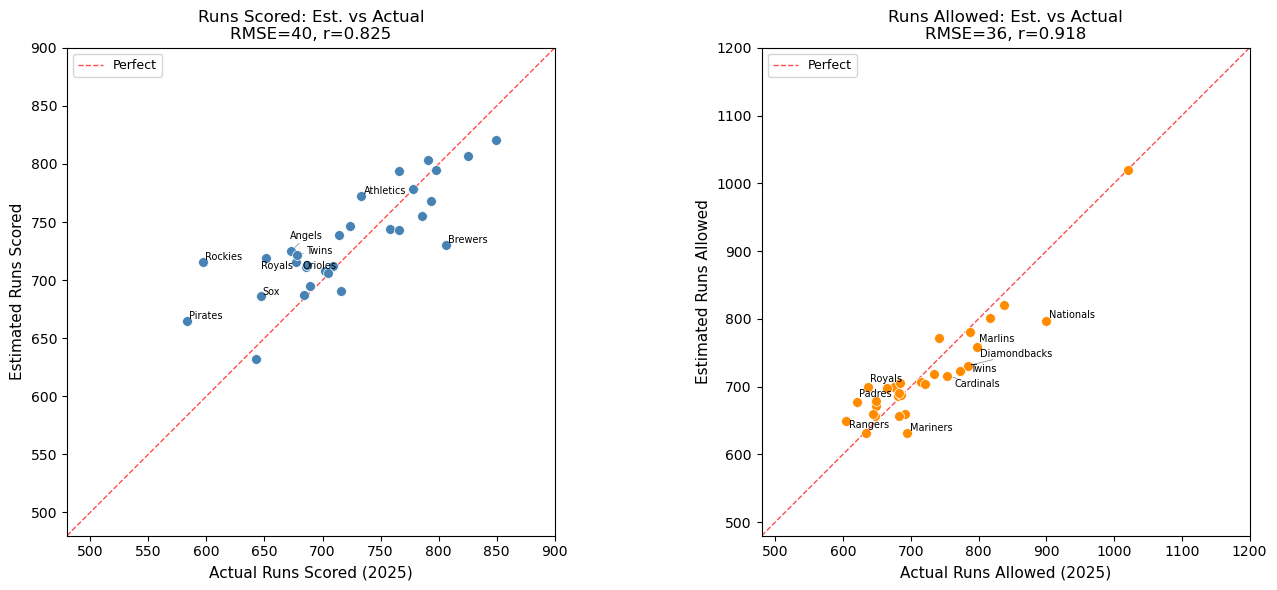

In [34]:
from adjustText import adjust_text

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# runs Scored
ax = axes[0]
ax.scatter(backtest["RS_actual"], backtest["RS_est"], s=50, c="steelblue", 
           edgecolors="white", linewidths=0.5, zorder=5)

rs_std = backtest["RS_diff"].std()
rs_texts = []
for _, row in backtest.iterrows():
    if abs(row["RS_diff"]) > rs_std:
        label = row["team"].split()[-1] if len(row["team"].split()) > 2 else row["team"].split()[-1]
        rs_texts.append(ax.text(row["RS_actual"], row["RS_est"], label, fontsize=7, zorder = 10))

lims = [480, 900]
ax.plot(lims, lims, "r--", linewidth=1, alpha=0.7, label="Perfect")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual Runs Scored (2025)", fontsize=11)
ax.set_ylabel("Estimated Runs Scored", fontsize=11)
ax.set_title(f"Runs Scored: Est. vs Actual\nRMSE={rs_rmse:.0f}, r={backtest['RS_est'].corr(backtest['RS_actual']):.3f}", fontsize=12)
ax.legend(fontsize=9)
ax.set_aspect("equal")
adjust_text(rs_texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

# Runs Allowed
ax = axes[1]
ax.scatter(backtest["RA_actual"], backtest["RA_est"], s=50, c="darkorange",
           edgecolors="white", linewidths=0.5, zorder=5)

ra_std = backtest["RA_diff"].std()
ra_texts = []
for _, row in backtest.iterrows():
    if abs(row["RA_diff"]) > ra_std:
        label = row["team"].split()[-1] if len(row["team"].split()) > 2 else row["team"].split()[-1]
        ra_texts.append(ax.text(row["RA_actual"], row["RA_est"], label, fontsize=7, zorder = 10))

lims = [480, 1200]
ax.plot(lims, lims, "r--", linewidth=1, alpha=0.7, label="Perfect")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual Runs Allowed (2025)", fontsize=11)
ax.set_ylabel("Estimated Runs Allowed", fontsize=11)
ax.set_title(f"Runs Allowed: Est. vs Actual\nRMSE={ra_rmse:.0f}, r={backtest['RA_est'].corr(backtest['RA_actual']):.3f}", fontsize=12)
ax.legend(fontsize=9)
ax.set_aspect("equal")
adjust_text(ra_texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

plt.tight_layout()
plt.show()

## 6. Full results table

In [36]:
display_cols = ["team", "park_factor", "RS_est", "RS_actual", "RS_diff",
                "RA_est", "RA_actual", "RA_diff", "wins_actual"]
print(backtest[display_cols].sort_values("wins_actual", ascending=False).to_string(index=False))

                 team  park_factor  RS_est  RS_actual  RS_diff  RA_est  RA_actual  RA_diff  wins_actual
    Milwaukee Brewers           99     730        806      -76     632        634       -2           97
Philadelphia Phillies          101     778        778        0     657        648        9           96
     New York Yankees           99     821        849      -28     687        685        2           94
    Toronto Blue Jays           99     795        798       -3     704        721      -17           94
  Los Angeles Dodgers           99     807        825      -18     657        683      -26           93
         Chicago Cubs           98     768        793      -25     671        649       22           92
     Seattle Mariners           94     743        766      -23     631        694      -63           90
     San Diego Padres           96     708        702        6     677        621       56           90
       Boston Red Sox          104     755        786      -31  